In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import numpy as np

In [7]:
data=pd.read_csv("Donnees_qualite_vins.csv")

In [8]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [18]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed acidity         1599 non-null   float64 
 1   volatile acidity      1599 non-null   float64 
 2   citric acid           1599 non-null   float64 
 3   residual sugar        1599 non-null   float64 
 4   chlorides             1599 non-null   float64 
 5   free sulfur dioxide   1599 non-null   float64 
 6   total sulfur dioxide  1599 non-null   float64 
 7   density               1599 non-null   float64 
 8   pH                    1599 non-null   float64 
 9   sulphates             1599 non-null   float64 
 10  alcohol               1599 non-null   float64 
 11  quality               1599 non-null   category
dtypes: category(1), float64(11)
memory usage: 139.2 KB


In [15]:
data["quality"]=data["quality"].astype("category")

In [16]:
data["quality"].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [17]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


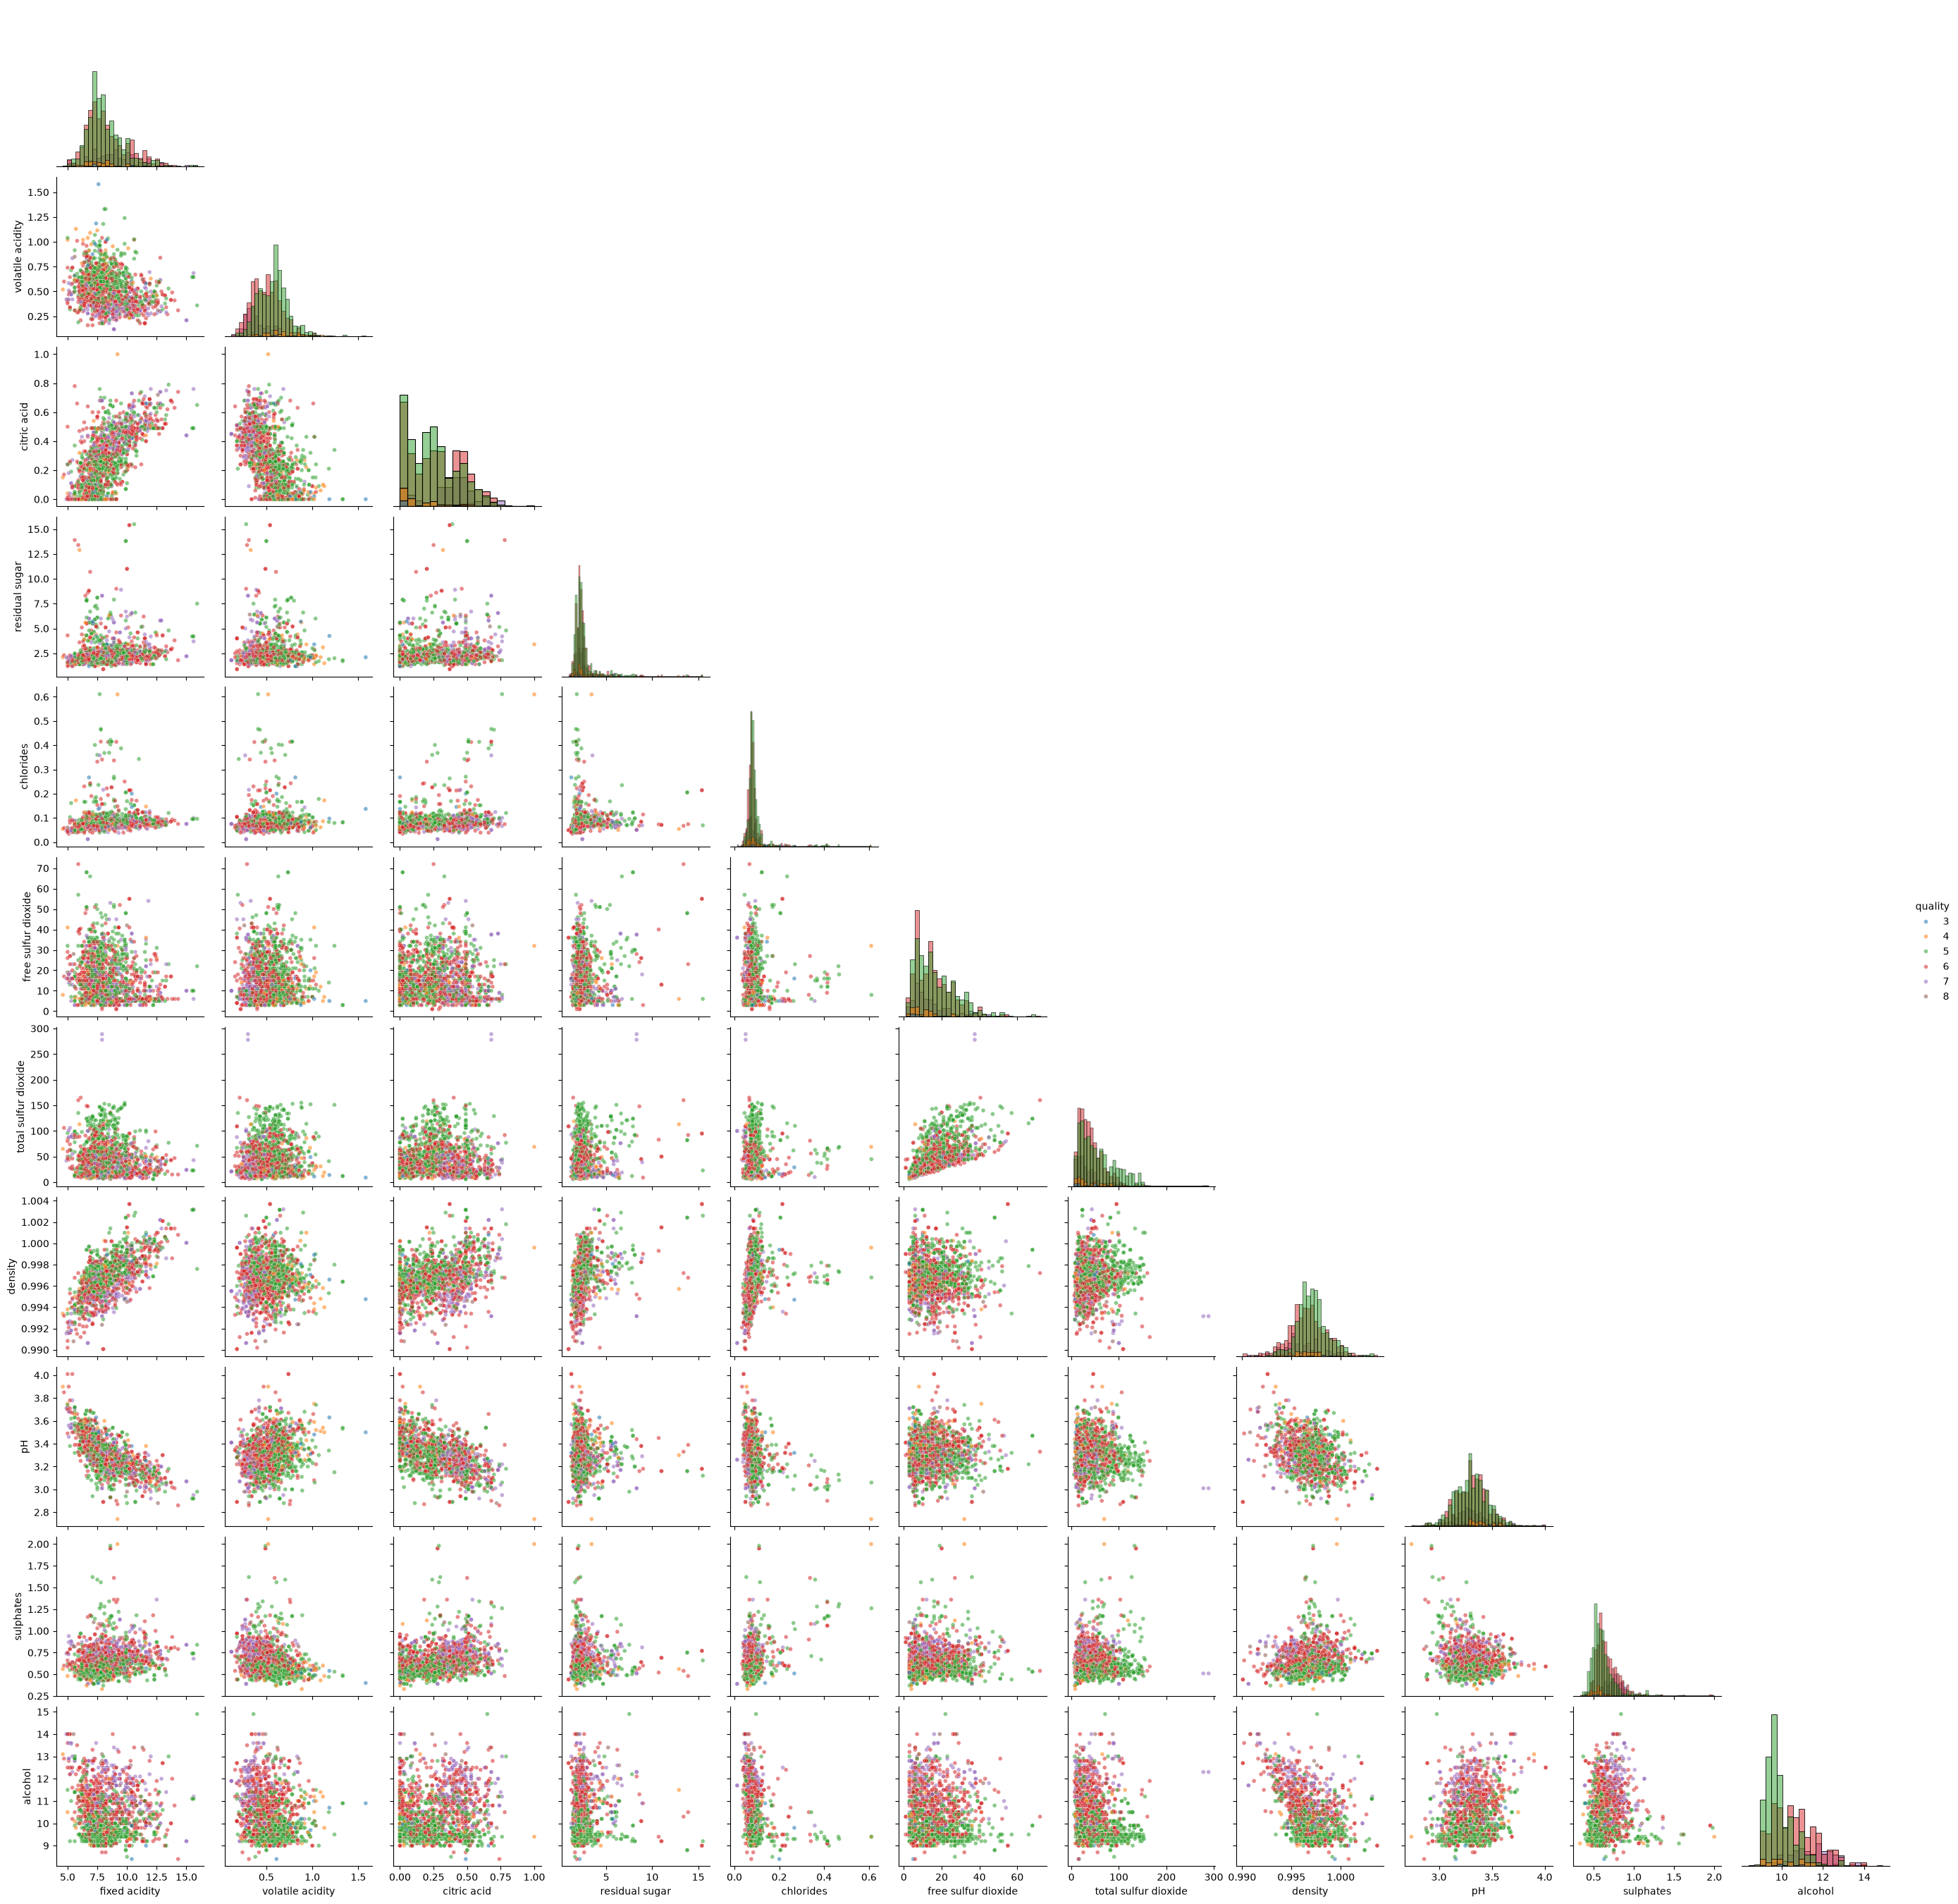

In [20]:
sns.pairplot(
    data,
    hue="quality",
    diag_kind="hist",
    corner=True,
    palette="tab10",
    plot_kws={"alpha": 0.55, "s": 18}
)

plt.show()

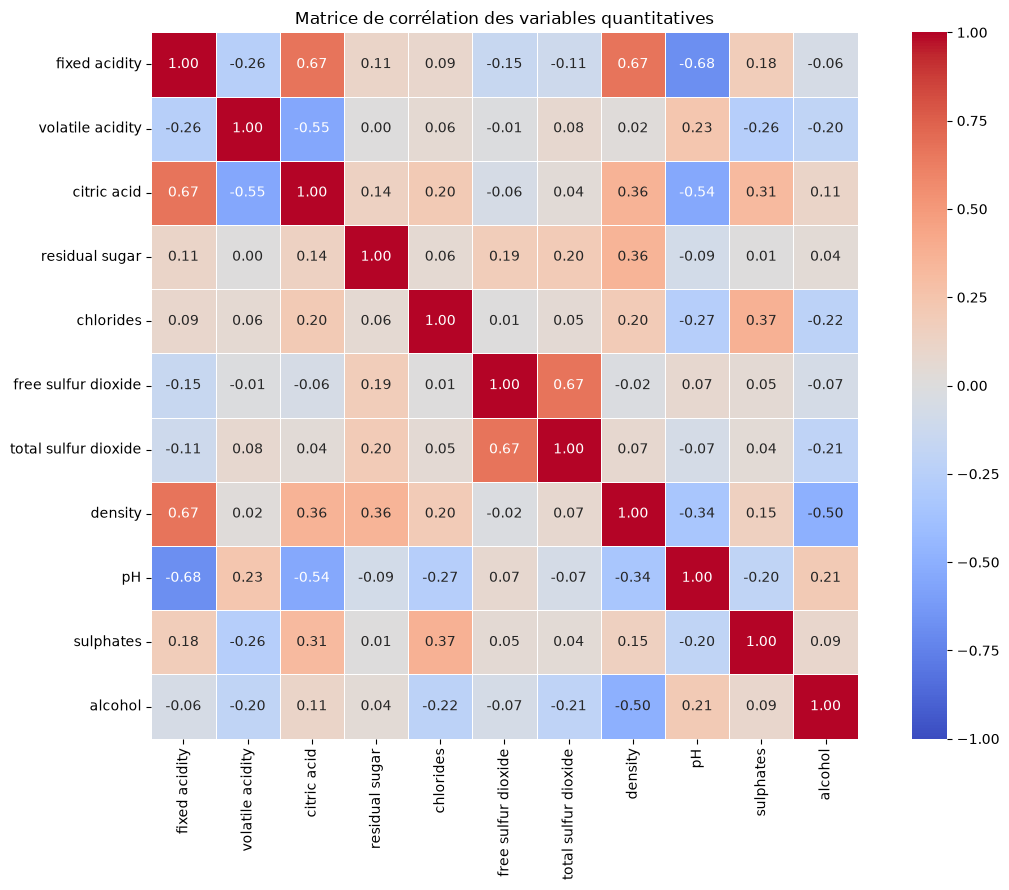

In [21]:
# Sélection des variables quantitatives uniquement
variables_quanti = data.select_dtypes(include="number")

# Calcul de la matrice de corrélation
matrice_corr = variables_quanti.corr()

# Affichage graphique
plt.figure(figsize=(12, 9))

sns.heatmap(
    matrice_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Matrice de corrélation des variables quantitatives")
plt.tight_layout()
plt.show()

In [ ]:
alpha = 0.05
variable_quali = "quality"

variables_quanti = data.select_dtypes(include="number").columns
categories = sorted(data[variable_quali].dropna().unique())

resultats_anova = []

for variable in variables_quanti:
    groupes = [
        data.loc[
            data[variable_quali] == categorie,
            variable
        ].dropna()
        for categorie in categories
    ]

    statistique_F, p_value = f_oneway(*groupes)

    if p_value < alpha:
        interpretation = "Différence significative"
    else:
        interpretation = "Pas de différence significative"

    resultats_anova.append({
        "Variable": variable,
        "Statistique F": statistique_F,
        "p-value": p_value,
        "Interprétation": interpretation
    })

table_anova = pd.DataFrame(resultats_anova)

# Arrondir les valeurs numériques
table_anova["Statistique F"] = table_anova["Statistique F"].round(3)
table_anova["p-value"] = table_anova["p-value"].map(
    lambda x: f"{x:.6f}"
)

print(table_anova.to_string(index=False))

            Variable  Statistique F  p-value                  Interprétation
       fixed acidity          6.283 0.000009        Différence significative
    volatile acidity         60.914 0.000000        Différence significative
         citric acid         19.691 0.000000        Différence significative
      residual sugar          1.053 0.384619 Pas de différence significative
           chlorides          6.036 0.000015        Différence significative
 free sulfur dioxide          4.754 0.000257        Différence significative
total sulfur dioxide         25.479 0.000000        Différence significative
             density         13.396 0.000000        Différence significative
                  pH          4.342 0.000628        Différence significative
           sulphates         22.273 0.000000        Différence significative
             alcohol        115.855 0.000000        Différence significative


/tmp/ipykernel_5797/4155945920.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="quality", y=col, ax=axes[i], palette="viridis")
/tmp/ipykernel_5797/4155945920.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="quality", y=col, ax=axes[i], palette="viridis")
/tmp/ipykernel_5797/4155945920.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="quality", y=col, ax=axes[i], palette="viridis")
/tmp/ipykernel_5797/4155945920.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecate

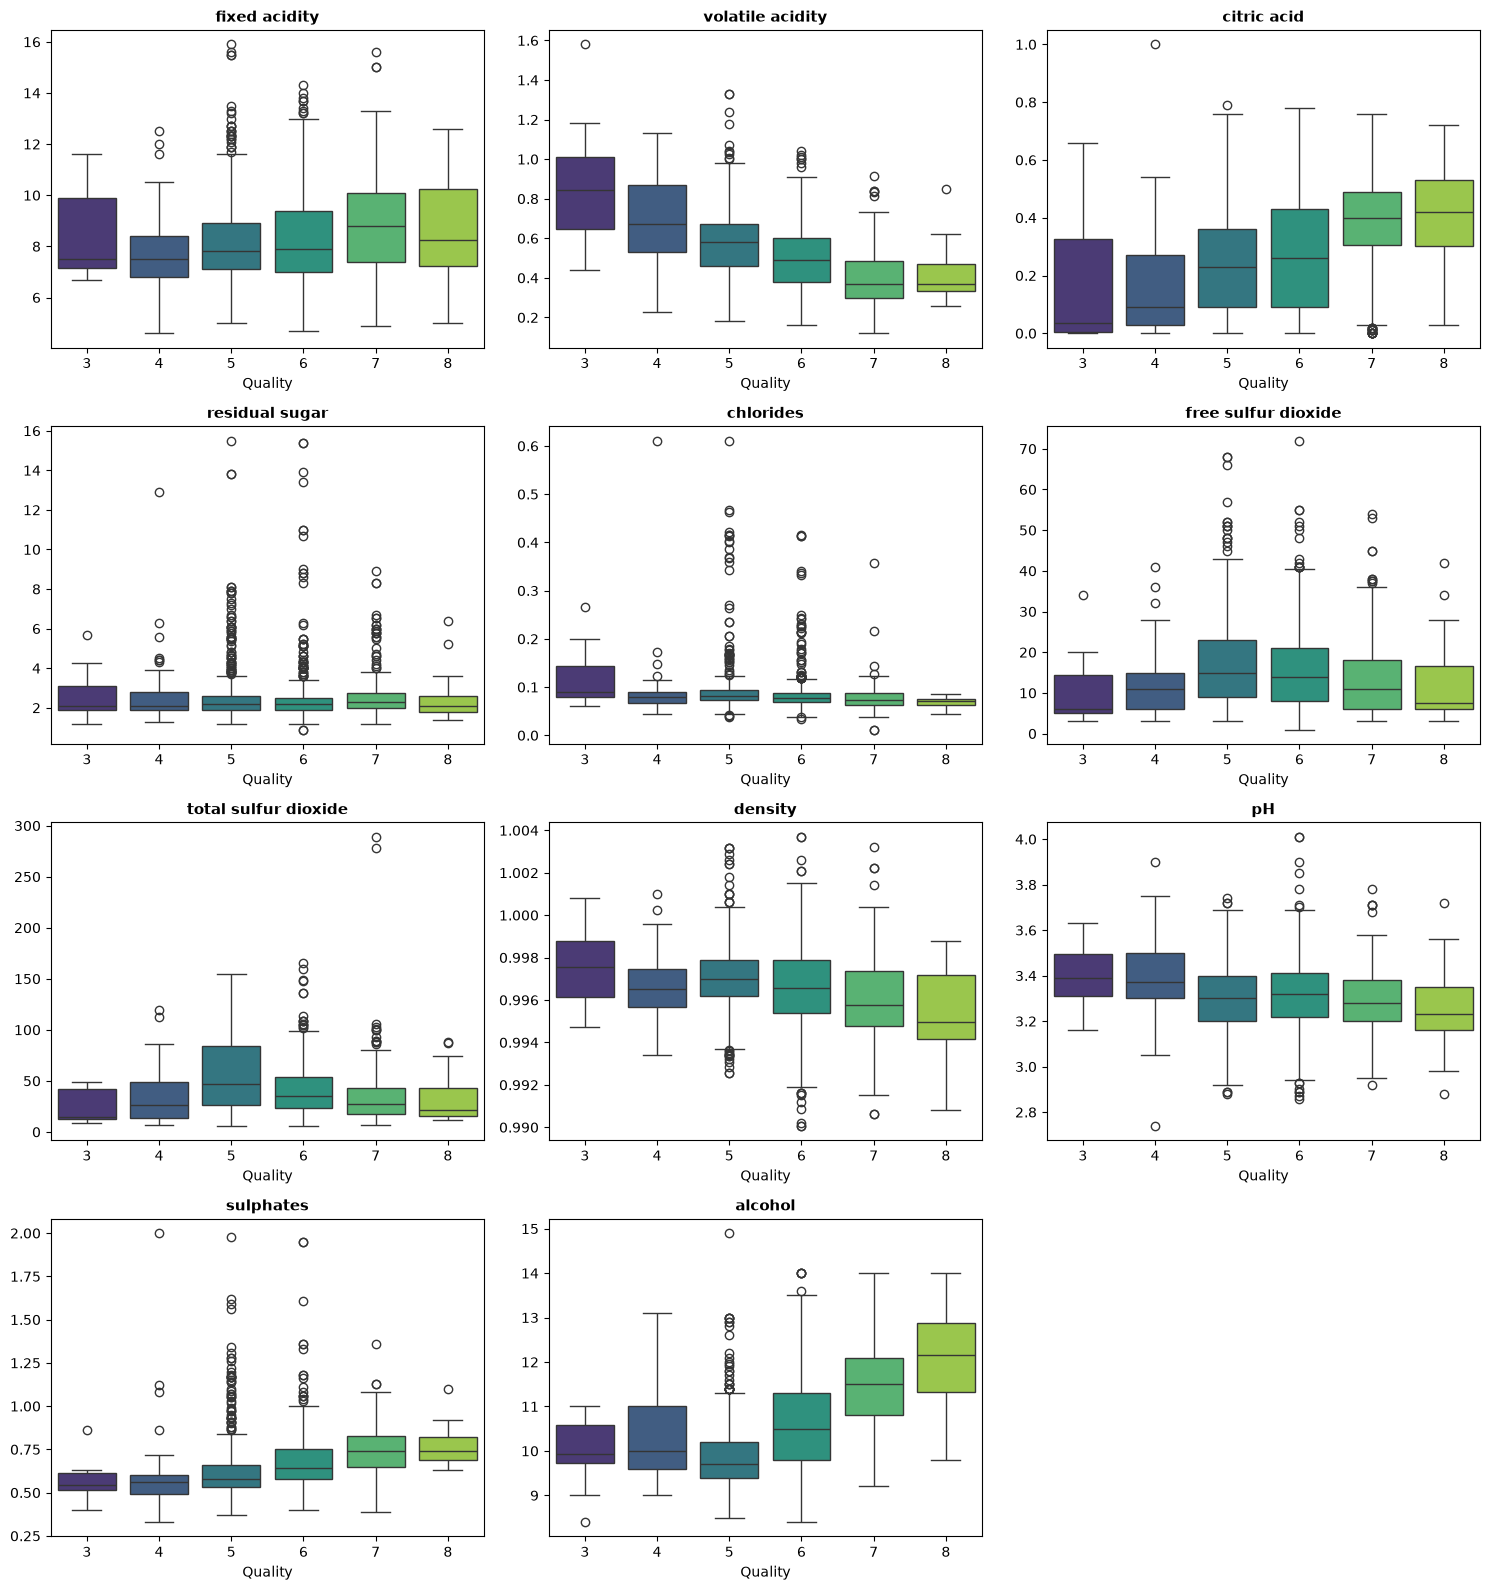

In [29]:
# Sélection des variables quantitatives
num_cols = data.select_dtypes(include=["float64", "int64"]).columns

# Création d'une grille 4x3
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 16))
axes = axes.flatten()

# Tracé d'un boxplot par variable
for i, col in enumerate(num_cols):
    sns.boxplot(data=data, x="quality", y=col, ax=axes[i], palette="viridis")
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Quality")
    axes[i].set_ylabel("")

# Suppression des axes inutilisés (12e emplacement)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()